# Neural Network Loan Approval Classification

Train a feed-forward neural network using one of two data preparation paths:

1. load the raw SMOTE training and raw test files, then normalize and encode them inside the neural-network pipeline; or
2. load the already normalized files generated by `07_smote_NN.ipynb`.

Change only `DATA_MODE` in the first code cell to switch between the paths. Hyperparameters are selected using randomized search with 5-fold stratified cross-validation.

# Initialization and Data Preparation

### Load data

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd

seed = 1
np.random.seed(seed)

PROJECT_ROOT = Path("..")
INPUT_DIR = PROJECT_ROOT / "data" / "pre-processed"
OUTPUT_DIR = PROJECT_ROOT / "models"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Choose one option:
# "raw"                -> raw train + raw test; preprocessing is done in this notebook.
# "raw_smote"          -> raw SMOTE train + raw test; preprocessing is done in this notebook.   - smote first, then normalized
# "processed_smote"    -> normalized SMOTE train + normalized test generated by notebook 07.    - normalized first, then smote
# "processed_no_smote" -> normalized original train + normalized test generated by notebook 07. - normalized, no smote
DATA_MODE = "raw"

if DATA_MODE == "raw":
    train_file = "loan_data_clean_train_3.csv"
    test_file = "loan_data_raw_test_1.csv"
    model_path = OUTPUT_DIR / "neural_network_raw.joblib"
    needs_preprocessing = True
elif DATA_MODE == "raw_smote":
    train_file = "loan_data_smoted_raw_train_4.csv"
    test_file = "loan_data_raw_test_1.csv"
    model_path = OUTPUT_DIR / "neural_network_raw_smote.joblib"
    needs_preprocessing = True
elif DATA_MODE == "processed_smote":
    train_file = "loan_data_nn_normal_train_smote.csv"
    test_file = "loan_data_nn_normal_test.csv"
    model_path = OUTPUT_DIR / "neural_network_smote.joblib"
    needs_preprocessing = False
elif DATA_MODE == "processed_no_smote":
    train_file = "loan_data_nn_normal_train.csv"
    test_file = "loan_data_nn_normal_test.csv"
    model_path = OUTPUT_DIR / "neural_network.joblib"
    needs_preprocessing = False
else:
    raise ValueError("DATA_MODE must be 'raw_smote', 'processed_smote', or 'processed_no_smote'.")

train_df = pd.read_csv(INPUT_DIR / train_file)
test_df = pd.read_csv(INPUT_DIR / test_file)

if set(train_df.columns) != set(test_df.columns):
    raise ValueError("The training and test files do not contain the same columns.")

test_df = test_df[train_df.columns]

print("Data mode:", DATA_MODE)
print("Training file:", train_file)
print("Test file:", test_file)
print("NN train data shape:", train_df.shape)
print("NN test data shape:", test_df.shape)

train_df.head()

Data mode: raw
Training file: loan_data_clean_train_3.csv
Test file: loan_data_raw_test_1.csv
NN train data shape: (34194, 13)
NN test data shape: (8999, 13)


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
0,31.0,female,2,44485.0,4,RENT,8000.0,PERSONAL,8.83,0.18,8.0,668,0
1,24.0,female,4,35851.0,0,RENT,8725.0,MEDICAL,12.18,0.24,2.0,645,0
2,28.0,female,1,121251.0,6,MORTGAGE,25000.0,VENTURE,11.01,0.21,6.0,569,1
3,23.0,female,1,76537.0,1,RENT,12000.0,MEDICAL,14.96,0.16,4.0,538,1
4,24.0,male,2,53633.0,4,RENT,23975.0,HOMEIMPROVEMENT,11.01,0.45,2.0,678,1


### Data Checks

In [17]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print()
print("Train columns:", train_df.columns.tolist())
print()
print("Missing values in training data:", train_df.isna().sum().sum())
print("Missing values in test data:", test_df.isna().sum().sum())
print("Train duplicate rows:", train_df.duplicated().sum())
print("Test duplicate rows:", test_df.duplicated().sum())

print()
print("Training target distribution:")
print(train_df["loan_status"].value_counts())
print()
print("Test target distribution:")
print(test_df["loan_status"].value_counts())

if needs_preprocessing:
    print()
    print("Raw categorical columns:", train_df.select_dtypes(include="object").columns.tolist())

Train shape: (34194, 13)
Test shape: (8999, 13)

Train columns: ['person_age', 'person_gender', 'person_education', 'person_income', 'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'loan_status']

Missing values in training data: 0
Missing values in test data: 0
Train duplicate rows: 0
Test duplicate rows: 0

Training target distribution:
loan_status
0    26765
1     7429
Name: count, dtype: int64

Test target distribution:
loan_status
0    6999
1    2000
Name: count, dtype: int64

Raw categorical columns: ['person_gender', 'person_home_ownership', 'loan_intent']


/var/folders/rf/t52_tqh94zzbcs4g3_xbghnh0000gn/T/ipykernel_14847/2555341263.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print("Raw categorical columns:", train_df.select_dtypes(include="object").columns.tolist())


### Create Training and Testing Data Matrices and Response Vectors

For `raw_smote`, continuous features are standardized and categorical features are one-hot encoded inside the model pipeline. `person_education` remains an ordinal value from 1 to 5, matching notebook 07.

For either processed mode, the files from notebook 07 are already normalized and encoded, so they are passed directly to the neural network.

In [18]:
response_col = "loan_status"

X_train = train_df.drop(columns=[response_col])
y_train = train_df[response_col]

X_test = test_df.drop(columns=[response_col])
y_test = test_df[response_col]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

if needs_preprocessing:
    print("Raw data will be normalized and encoded inside the pipeline.")
else:
    print("All predictors numeric:", X_train.select_dtypes(exclude=np.number).empty)

X_train shape: (34194, 12)
y_train shape: (34194,)
X_test shape: (8999, 12)
y_test shape: (8999,)
Raw data will be normalized and encoded inside the pipeline.


# Neural Network Implementation

### Neural Network Tuning

In [19]:
from scipy.stats import loguniform
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

nn_model = MLPClassifier(
    solver="adam",
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=12,
    random_state=seed,
)

if needs_preprocessing:
    education_col = "person_education"
    categorical_cols = X_train.select_dtypes(include="object").columns.tolist()
    continuous_cols = X_train.select_dtypes(exclude="object").columns.tolist()
    continuous_cols.remove(education_col)

    preprocessor = ColumnTransformer([
        ("continuous", StandardScaler(), continuous_cols),
        ("education", "passthrough", [education_col]),
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
    ], sparse_threshold=0)

    nn_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", nn_model),
    ])

    print("Continuous columns normalized:", continuous_cols)
    print("Ordinal column kept as 1-5:", education_col)
    print("Categorical columns one-hot encoded:", categorical_cols)
else:
    nn_pipeline = Pipeline([
        ("model", nn_model),
    ])

param_distributions = {
    "model__hidden_layer_sizes": [(32,), (64,), (128,), (64, 32), (128, 64), (128, 64, 32)],
    "model__activation": ["relu", "tanh"],
    "model__alpha": loguniform(1e-5, 1e-2),
    "model__learning_rate_init": loguniform(1e-4, 5e-3),
    "model__batch_size": [64, 128, 256],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

nn_search = RandomizedSearchCV(
    estimator=nn_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="f1",
    cv=cv,
    random_state=seed,
    n_jobs=-1,
    verbose=2,
    return_train_score=True,
)

nn_search.fit(X_train, y_train)

Continuous columns normalized: ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']
Ordinal column kept as 1-5: person_education
Categorical columns one-hot encoded: ['person_gender', 'person_home_ownership', 'loan_intent']
Fitting 5 folds for each of 20 candidates, totalling 100 fits


/var/folders/rf/t52_tqh94zzbcs4g3_xbghnh0000gn/T/ipykernel_14847/2357296517.py:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include="object").columns.tolist()


[CV] END model__activation=tanh, model__alpha=0.009807412289900458, model__batch_size=64, model__hidden_layer_sizes=(64,), model__learning_rate_init=0.00032632772421791866; total time=   4.7s
[CV] END model__activation=tanh, model__alpha=0.009807412289900458, model__batch_size=64, model__hidden_layer_sizes=(64,), model__learning_rate_init=0.00032632772421791866; total time=   6.0s
[CV] END model__activation=tanh, model__alpha=5.108188686258303e-05, model__batch_size=128, model__hidden_layer_sizes=(128, 64), model__learning_rate_init=0.000456088071202065; total time=   8.6s
[CV] END model__activation=tanh, model__alpha=5.108188686258303e-05, model__batch_size=128, model__hidden_layer_sizes=(128, 64), model__learning_rate_init=0.000456088071202065; total time=   9.6s
[CV] END model__activation=tanh, model__alpha=0.009807412289900458, model__batch_size=64, model__hidden_layer_sizes=(64,), model__learning_rate_init=0.00032632772421791866; total time=  11.0s
[CV] END model__activation=tanh,

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...om_state=1))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__activation': ['relu', 'tanh'], 'model__alpha': <scipy.stats....t 0x12a7b6060>, 'model__batch_size': [64, 128, ...], 'model__hidden_layer_sizes': [(32,), (64,), ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",1
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyex

### Best Hyperparameters and Cross-Validation Results

In [20]:
print("Best CV F1 score:", round(nn_search.best_score_, 4))
print("Best parameters:")
for name, value in nn_search.best_params_.items():
    print(f"{name}: {value}")

search_results = pd.DataFrame(nn_search.cv_results_).sort_values("rank_test_score")
search_results[["rank_test_score", "mean_train_score", "mean_test_score", "std_test_score", "mean_fit_time", "params"]].head(10)

Best CV F1 score: 0.7273
Best parameters:
model__activation: tanh
model__alpha: 5.108188686258303e-05
model__batch_size: 128
model__hidden_layer_sizes: (128, 64)
model__learning_rate_init: 0.000456088071202065


,rank_test_score,mean_train_score,mean_test_score,std_test_score,mean_fit_time,params
1,1,0.742727,0.727315,0.005599,9.726290,"{'model__activation': 'tanh', 'model__alpha': ..."
9,2,0.745131,0.725757,0.004717,4.135204,"{'model__activation': 'relu', 'model__alpha': ..."
18,3,0.742854,0.723877,0.014843,3.806290,"{'model__activation': 'tanh', 'model__alpha': ..."
15,4,0.740013,0.723743,0.005704,4.872719,"{'model__activation': 'relu', 'model__alpha': ..."
17,5,0.741238,0.722285,0.007278,5.475964,"{'model__activation': 'tanh', 'model__alpha': ..."
5,6,0.740771,0.722042,0.010187,3.917339,"{'model__activation': 'relu', 'model__alpha': ..."
6,7,0.735624,0.719774,0.010459,2.280031,"{'model__activation': 'tanh', 'model__alpha': ..."
14,8,0.739795,0.718478,0.009161,2.521535,"{'model__activation': 'relu', 'model__alpha': ..."
13,9,0.732926,0.718312,0.008461,1.662206,"{'model__activation': 'tanh', 'model__alpha': ..."
19,10,0.741494,0.717391,0.008915,6.059778,"{'model__activation': 'relu', 'model__alpha': ..."


### Test Set Evaluation

In [21]:
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

best_nn_model = nn_search.best_estimator_
class_labels = best_nn_model.named_steps["model"].classes_
y_proba = best_nn_model.predict_proba(X_test)[:, 1]
y_pred = best_nn_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
by_class_accuracy = cm.diagonal() / cm.sum(axis=1)

print("Test accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Test precision:", round(precision_score(y_test, y_pred), 4))
print("Test recall:", round(recall_score(y_test, y_pred), 4))
print("Test F1 score:", round(f1_score(y_test, y_pred), 4))
print("Test ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))
print("Test PR-AUC:", round(average_precision_score(y_test, y_proba), 4))

print()
print("Confusion matrix: Row = actual class, Column = predicted class")
print(cm)
print()
print("By-class accuracy:")
for class_label, accuracy in zip(class_labels, by_class_accuracy):
    print(f"Class {class_label}: {accuracy:.4f}")

print()
print("Classification report:")
print(classification_report(y_test, y_pred))

Test accuracy: 0.8953
Test precision: 0.8604
Test recall: 0.6315
Test F1 score: 0.7284
Test ROC-AUC: 0.9043
Test PR-AUC: 0.8255

Confusion matrix: Row = actual class, Column = predicted class
[[6794  205]
 [ 737 1263]]

By-class accuracy:
Class 0: 0.9707
Class 1: 0.6315

Classification report:
              precision    recall  f1-score   support

           0       0.90      0.97      0.94      6999
           1       0.86      0.63      0.73      2000

    accuracy                           0.90      8999
   macro avg       0.88      0.80      0.83      8999
weighted avg       0.89      0.90      0.89      8999



### Confusion Matrix

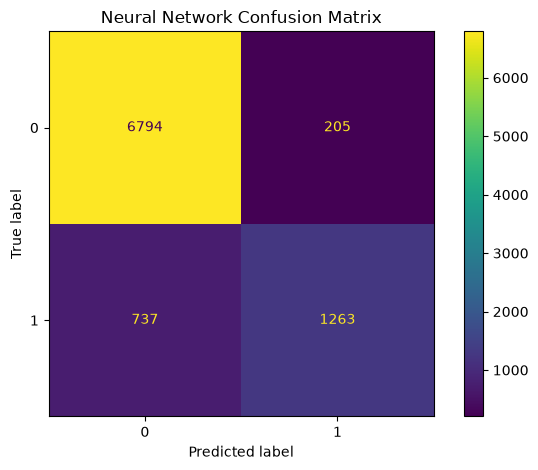

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels).plot(values_format="d")
plt.title("Neural Network Confusion Matrix")
plt.tight_layout()
plt.show()

### ROC Curve

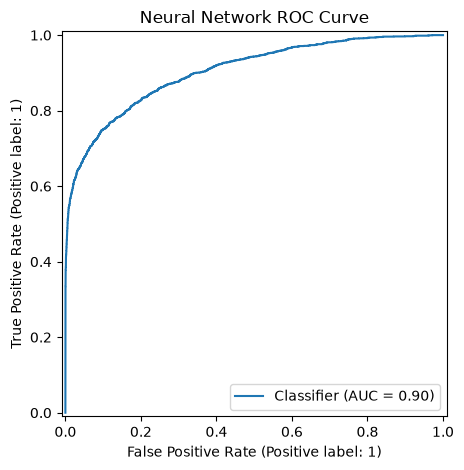

In [23]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("Neural Network ROC Curve")
plt.tight_layout()
plt.show()

### Precision-Recall Curve

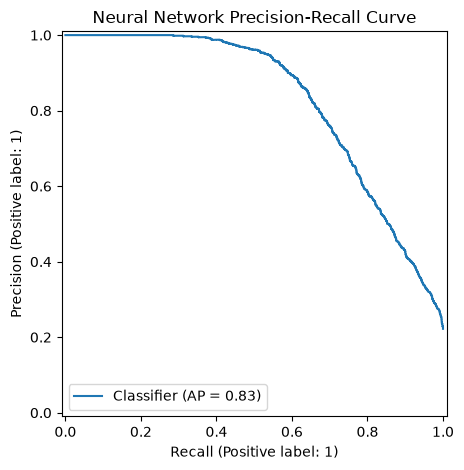

In [24]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.title("Neural Network Precision-Recall Curve")
plt.tight_layout()
plt.show()

### Training History of the Best Model

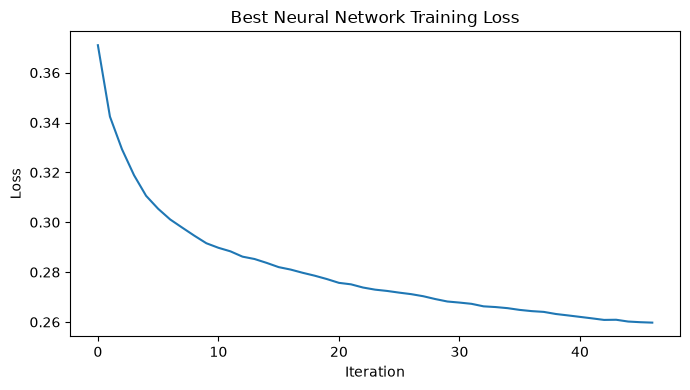

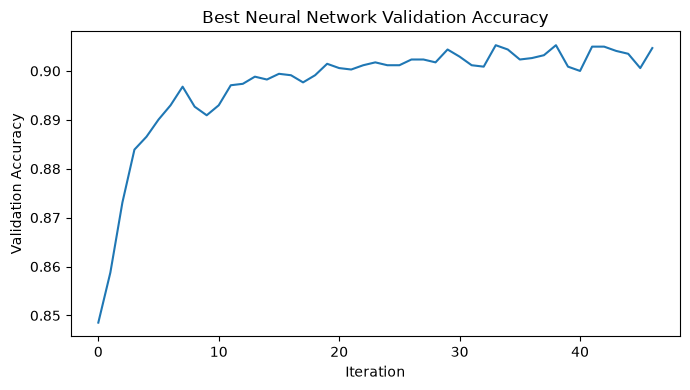

Iterations used: 47
Final training loss: 0.259748


In [25]:
best_mlp = best_nn_model.named_steps["model"]

plt.figure(figsize=(7, 4))
plt.plot(best_mlp.loss_curve_)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Best Neural Network Training Loss")
plt.tight_layout()
plt.show()

if best_mlp.validation_scores_ is not None:
    plt.figure(figsize=(7, 4))
    plt.plot(best_mlp.validation_scores_)
    plt.xlabel("Iteration")
    plt.ylabel("Validation Accuracy")
    plt.title("Best Neural Network Validation Accuracy")
    plt.tight_layout()
    plt.show()

print("Iterations used:", best_mlp.n_iter_)
print("Final training loss:", round(best_mlp.loss_, 6))

### Save the Tuned Model

In [26]:
from joblib import dump

dump(best_nn_model, model_path)
print("Saved model to:", model_path)

Saved model to: ../models/neural_network_raw.joblib
